# Steered

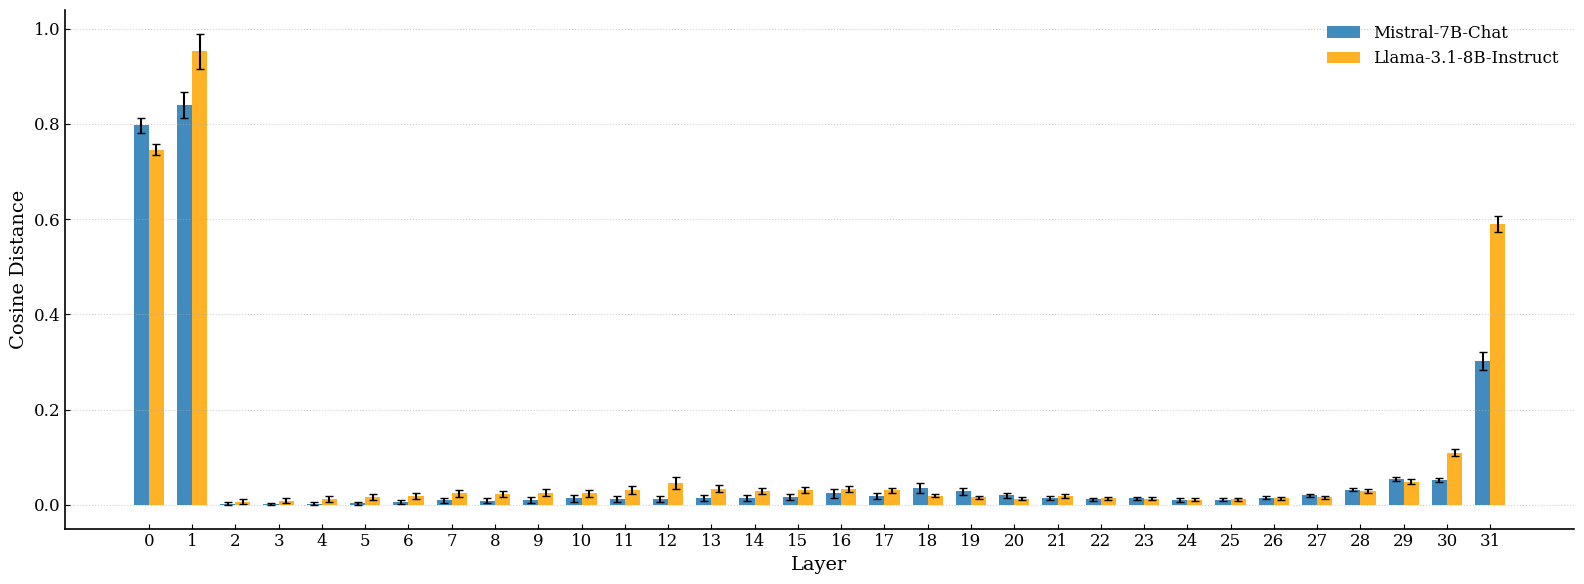

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import re

# Your raw text data
mistral_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0162
[Layer:] 1 | Cosine Distance [Mean:] 0.8398 [Std:] 0.0272
[Layer:] 2 | Cosine Distance [Mean:] 0.0020 [Std:] 0.0027
[Layer:] 3 | Cosine Distance [Mean:] 0.0015 [Std:] 0.0020
[Layer:] 4 | Cosine Distance [Mean:] 0.0021 [Std:] 0.0027
[Layer:] 5 | Cosine Distance [Mean:] 0.0031 [Std:] 0.0034
[Layer:] 6 | Cosine Distance [Mean:] 0.0054 [Std:] 0.0046
[Layer:] 7 | Cosine Distance [Mean:] 0.0088 [Std:] 0.0054
[Layer:] 8 | Cosine Distance [Mean:] 0.0087 [Std:] 0.0053
[Layer:] 9 | Cosine Distance [Mean:] 0.0095 [Std:] 0.0056
[Layer:] 10 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0077
[Layer:] 11 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0067
[Layer:] 12 | Cosine Distance [Mean:] 0.0117 [Std:] 0.0067
[Layer:] 13 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0066
[Layer:] 14 | Cosine Distance [Mean:] 0.0130 [Std:] 0.0063
[Layer:] 15 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0067
[Layer:] 16 | Cosine Distance [Mean:] 0.0238 [Std:] 0.0092
[Layer:] 17 | Cosine Distance [Mean:] 0.0181 [Std:] 0.0064
[Layer:] 18 | Cosine Distance [Mean:] 0.0342 [Std:] 0.0105
[Layer:] 19 | Cosine Distance [Mean:] 0.0283 [Std:] 0.0074
[Layer:] 20 | Cosine Distance [Mean:] 0.0193 [Std:] 0.0056
[Layer:] 21 | Cosine Distance [Mean:] 0.0133 [Std:] 0.0040
[Layer:] 22 | Cosine Distance [Mean:] 0.0112 [Std:] 0.0037
[Layer:] 23 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0040
[Layer:] 24 | Cosine Distance [Mean:] 0.0098 [Std:] 0.0036
[Layer:] 25 | Cosine Distance [Mean:] 0.0102 [Std:] 0.0035
[Layer:] 26 | Cosine Distance [Mean:] 0.0150 [Std:] 0.0034
[Layer:] 27 | Cosine Distance [Mean:] 0.0198 [Std:] 0.0034
[Layer:] 28 | Cosine Distance [Mean:] 0.0315 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0542 [Std:] 0.0042
[Layer:] 30 | Cosine Distance [Mean:] 0.0527 [Std:] 0.0041
[Layer:] 31 | Cosine Distance [Mean:] 0.3027 [Std:] 0.0188
"""

llama_data_raw = """
[Layer:] 0 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0116
[Layer:] 1 | Cosine Distance [Mean:] 0.9531 [Std:] 0.0369
[Layer:] 2 | Cosine Distance [Mean:] 0.0063 [Std:] 0.0047
[Layer:] 3 | Cosine Distance [Mean:] 0.0086 [Std:] 0.0048
[Layer:] 4 | Cosine Distance [Mean:] 0.0125 [Std:] 0.0059
[Layer:] 5 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0065
[Layer:] 6 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0069
[Layer:] 7 | Cosine Distance [Mean:] 0.0237 [Std:] 0.0081
[Layer:] 8 | Cosine Distance [Mean:] 0.0219 [Std:] 0.0067
[Layer:] 9 | Cosine Distance [Mean:] 0.0253 [Std:] 0.0077
[Layer:] 10 | Cosine Distance [Mean:] 0.0242 [Std:] 0.0075
[Layer:] 11 | Cosine Distance [Mean:] 0.0308 [Std:] 0.0088
[Layer:] 12 | Cosine Distance [Mean:] 0.0459 [Std:] 0.0125
[Layer:] 13 | Cosine Distance [Mean:] 0.0337 [Std:] 0.0081
[Layer:] 14 | Cosine Distance [Mean:] 0.0286 [Std:] 0.0062
[Layer:] 15 | Cosine Distance [Mean:] 0.0309 [Std:] 0.0073
[Layer:] 16 | Cosine Distance [Mean:] 0.0339 [Std:] 0.0063
[Layer:] 17 | Cosine Distance [Mean:] 0.0298 [Std:] 0.0055
[Layer:] 18 | Cosine Distance [Mean:] 0.0189 [Std:] 0.0037
[Layer:] 19 | Cosine Distance [Mean:] 0.0156 [Std:] 0.0036
[Layer:] 20 | Cosine Distance [Mean:] 0.0128 [Std:] 0.0032
[Layer:] 21 | Cosine Distance [Mean:] 0.0179 [Std:] 0.0036
[Layer:] 22 | Cosine Distance [Mean:] 0.0131 [Std:] 0.0030
[Layer:] 23 | Cosine Distance [Mean:] 0.0122 [Std:] 0.0030
[Layer:] 24 | Cosine Distance [Mean:] 0.0106 [Std:] 0.0026
[Layer:] 25 | Cosine Distance [Mean:] 0.0111 [Std:] 0.0026
[Layer:] 26 | Cosine Distance [Mean:] 0.0135 [Std:] 0.0030
[Layer:] 27 | Cosine Distance [Mean:] 0.0159 [Std:] 0.0033
[Layer:] 28 | Cosine Distance [Mean:] 0.0281 [Std:] 0.0038
[Layer:] 29 | Cosine Distance [Mean:] 0.0483 [Std:] 0.0050
[Layer:] 30 | Cosine Distance [Mean:] 0.1094 [Std:] 0.0075
[Layer:] 31 | Cosine Distance [Mean:] 0.5898 [Std:] 0.0167
"""

def parse_data(raw_text):
    means = []
    stds = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            # Extract Mean and Std using regex
            match = re.search(r'\[Mean:\] ([\d.]+) \[Std:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
                stds.append(float(match.group(2)))
    return means, stds

# Parse the data
m_means, m_stds = parse_data(mistral_data_raw)
l_means, l_stds = parse_data(llama_data_raw)

# X-axis locations and bar width
layers = np.arange(len(m_means))
width = 0.35

# Apply academic styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,              
    'axes.labelsize': 14,         
    'axes.titlesize': 14,
    'figure.figsize': (16.0, 6.0), # Wide figure to fit 32 layers side-by-side
    'axes.spines.top': False,     
    'axes.spines.right': False
})

fig, ax = plt.subplots()

# Create grouped bar charts with error bars. Note the `+ width/2` for LLaMA to prevent overlap.
rects1 = ax.bar(layers - width/2, m_means, width, yerr=m_stds, label='Mistral-7B-Chat', color='#1f77b4', capsize=3, alpha=0.85)
rects2 = ax.bar(layers + width/2, l_means, width, yerr=l_stds, label='Llama-3.1-8B-Instruct', color='orange', capsize=3, alpha=0.85)

# Formatting
ax.set_xlabel('Layer')
ax.set_ylabel('Cosine Distance')
ax.set_xticks(layers)
ax.set_xticklabels(layers)
ax.grid(True, linestyle=':', alpha=0.6, axis='y')

# Render the legend without a box frame, positioned in the top left
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
# plt.savefig('cosine_distance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0103 | [Max:] 1.0117 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.7656 [Std:] 0.0621 | [Max:] 0.9102 [Min:] 0.4648
[Layer:] 2 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0514 | [Max:] 0.8555 [Min:] 0.5508
[Layer:] 3 | Cosine Distance [Mean:] 0.6504 [Std:] 0.0443 | [Max:] 0.8145 [Min:] 0.5469
[Layer:] 4 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0347 | [Max:] 0.7910 [Min:] 0.5703
[Layer:] 5 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0276 | [Max:] 0.7773 [Min:] 0.6016
[Layer:] 6 | Cosine Distance [Mean:] 0.6582 [Std:] 0.0214 | [Max:] 0.7754 [Min:] 0.6211
[Layer:] 7 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0206 | [Max:] 0.7617 [Min:] 0.6250
[Layer:] 8 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0173 | [Max:] 0.7559 [Min:] 0.6211
[Layer:] 9 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0148 | [Max:] 0.7383 [Min:] 0.6191
[Layer:] 10 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0136 | [Max:] 0.7129 [Min:] 0.5996
[Layer:] 11 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0115 | [Max:] 0.7129 [Min:] 0.6211
[Layer:] 12 | Cosine Distance [Mean:] 0.6465 [Std:] 0.0184 | [Max:] 0.7031 [Min:] 0.6172
[Layer:] 13 | Cosine Distance [Mean:] 0.6543 [Std:] 0.0255 | [Max:] 0.7188 [Min:] 0.6191
[Layer:] 14 | Cosine Distance [Mean:] 0.6660 [Std:] 0.0172 | [Max:] 0.7188 [Min:] 0.6445
[Layer:] 15 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0161 | [Max:] 0.7188 [Min:] 0.6543
[Layer:] 16 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0131 | [Max:] 0.7031 [Min:] 0.6582
[Layer:] 17 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0160 | [Max:] 0.7422 [Min:] 0.6836
[Layer:] 18 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0085 | [Max:] 0.7324 [Min:] 0.6895
[Layer:] 19 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0073 | [Max:] 0.7207 [Min:] 0.6797
[Layer:] 20 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0059 | [Max:] 0.7148 [Min:] 0.6777
[Layer:] 21 | Cosine Distance [Mean:] 0.6738 [Std:] 0.0067 | [Max:] 0.6992 [Min:] 0.6582
[Layer:] 22 | Cosine Distance [Mean:] 0.6660 [Std:] 0.0098 | [Max:] 0.6953 [Min:] 0.6465
[Layer:] 23 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0105 | [Max:] 0.6797 [Min:] 0.6387
[Layer:] 24 | Cosine Distance [Mean:] 0.6387 [Std:] 0.0128 | [Max:] 0.6719 [Min:] 0.6211
[Layer:] 25 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0110 | [Max:] 0.6719 [Min:] 0.6289
[Layer:] 26 | Cosine Distance [Mean:] 0.6543 [Std:] 0.0171 | [Max:] 0.6914 [Min:] 0.6328
[Layer:] 27 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0150 | [Max:] 0.7031 [Min:] 0.6543
[Layer:] 28 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0205 | [Max:] 0.7227 [Min:] 0.6680
[Layer:] 29 | Cosine Distance [Mean:] 0.7109 [Std:] 0.0249 | [Max:] 0.7500 [Min:] 0.6836
[Layer:] 30 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0142 | [Max:] 0.7930 [Min:] 0.7441
[Layer:] 31 | Cosine Distance [Mean:] 0.7812 [Std:] 0.0076 | [Max:] 0.8066 [Min:] 0.7656
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 1 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0452 | [Max:] 0.7656 [Min:] 0.4785
[Layer:] 2 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0165 | [Max:] 0.6797 [Min:] 0.5723
[Layer:] 3 | Cosine Distance [Mean:] 0.6465 [Std:] 0.0098 | [Max:] 0.6836 [Min:] 0.6309
[Layer:] 4 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0042 | [Max:] 0.6953 [Min:] 0.6738
[Layer:] 5 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0024 | [Max:] 0.7305 [Min:] 0.7129
[Layer:] 6 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0071 | [Max:] 0.7188 [Min:] 0.6992
[Layer:] 7 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0008 | [Max:] 0.7031 [Min:] 0.6953
[Layer:] 8 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0038 | [Max:] 0.7070 [Min:] 0.6914
[Layer:] 9 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0033 | [Max:] 0.7305 [Min:] 0.7148
[Layer:] 10 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0035 | [Max:] 0.7227 [Min:] 0.7070
[Layer:] 11 | Cosine Distance [Mean:] 0.7246 [Std:] 0.0036 | [Max:] 0.7383 [Min:] 0.7207
[Layer:] 12 | Cosine Distance [Mean:] 0.7480 [Std:] 0.0032 | [Max:] 0.7578 [Min:] 0.7422
[Layer:] 13 | Cosine Distance [Mean:] 0.7637 [Std:] 0.0032 | [Max:] 0.7734 [Min:] 0.7578
[Layer:] 14 | Cosine Distance [Mean:] 0.7715 [Std:] 0.0074 | [Max:] 0.7891 [Min:] 0.7617
[Layer:] 15 | Cosine Distance [Mean:] 0.7461 [Std:] 0.0030 | [Max:] 0.7539 [Min:] 0.7422
[Layer:] 16 | Cosine Distance [Mean:] 0.7422 [Std:] 0.0041 | [Max:] 0.7539 [Min:] 0.7344
[Layer:] 17 | Cosine Distance [Mean:] 0.7324 [Std:] 0.0038 | [Max:] 0.7422 [Min:] 0.7227
[Layer:] 18 | Cosine Distance [Mean:] 0.7012 [Std:] 0.0032 | [Max:] 0.7109 [Min:] 0.6914
[Layer:] 19 | Cosine Distance [Mean:] 0.6797 [Std:] 0.0062 | [Max:] 0.6953 [Min:] 0.6680
[Layer:] 20 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0051 | [Max:] 0.6875 [Min:] 0.6562
[Layer:] 21 | Cosine Distance [Mean:] 0.6426 [Std:] 0.0042 | [Max:] 0.6562 [Min:] 0.6309
[Layer:] 22 | Cosine Distance [Mean:] 0.6211 [Std:] 0.0044 | [Max:] 0.6367 [Min:] 0.6113
[Layer:] 23 | Cosine Distance [Mean:] 0.5996 [Std:] 0.0036 | [Max:] 0.6152 [Min:] 0.5898
[Layer:] 24 | Cosine Distance [Mean:] 0.5957 [Std:] 0.0046 | [Max:] 0.6094 [Min:] 0.5859
[Layer:] 25 | Cosine Distance [Mean:] 0.6016 [Std:] 0.0025 | [Max:] 0.6133 [Min:] 0.5898
[Layer:] 26 | Cosine Distance [Mean:] 0.6016 [Std:] 0.0083 | [Max:] 0.6133 [Min:] 0.5859
[Layer:] 27 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0090 | [Max:] 0.6328 [Min:] 0.6016
[Layer:] 28 | Cosine Distance [Mean:] 0.6328 [Std:] 0.0096 | [Max:] 0.6484 [Min:] 0.6172
[Layer:] 29 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0045 | [Max:] 0.6562 [Min:] 0.6348
[Layer:] 30 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0050 | [Max:] 0.7031 [Min:] 0.6836
[Layer:] 31 | Cosine Distance [Mean:] 0.7422 [Std:] 0.0014 | [Max:] 0.7500 [Min:] 0.7383
"""

In [75]:
# Your raw text data
mistral_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0048 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 1 | Cosine Distance [Mean:] 0.7910 [Std:] 0.0642 | [Max:] 0.9043 [Min:] 0.5625
[Layer:] 2 | Cosine Distance [Mean:] 0.7148 [Std:] 0.0616 | [Max:] 0.8438 [Min:] 0.5586
[Layer:] 3 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0580 | [Max:] 0.7930 [Min:] 0.5332
[Layer:] 4 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0499 | [Max:] 0.7617 [Min:] 0.5352
[Layer:] 5 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0411 | [Max:] 0.7480 [Min:] 0.5625
[Layer:] 6 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0331 | [Max:] 0.7480 [Min:] 0.5957
[Layer:] 7 | Cosine Distance [Mean:] 0.6328 [Std:] 0.0323 | [Max:] 0.7305 [Min:] 0.5859
[Layer:] 8 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0270 | [Max:] 0.7188 [Min:] 0.5957
[Layer:] 9 | Cosine Distance [Mean:] 0.6074 [Std:] 0.0250 | [Max:] 0.6895 [Min:] 0.5762
[Layer:] 10 | Cosine Distance [Mean:] 0.5801 [Std:] 0.0232 | [Max:] 0.6621 [Min:] 0.5547
[Layer:] 11 | Cosine Distance [Mean:] 0.5918 [Std:] 0.0180 | [Max:] 0.6582 [Min:] 0.5684
[Layer:] 12 | Cosine Distance [Mean:] 0.6055 [Std:] 0.0155 | [Max:] 0.6523 [Min:] 0.5801
[Layer:] 13 | Cosine Distance [Mean:] 0.6152 [Std:] 0.0171 | [Max:] 0.6562 [Min:] 0.5879
[Layer:] 14 | Cosine Distance [Mean:] 0.6250 [Std:] 0.0138 | [Max:] 0.6641 [Min:] 0.6055
[Layer:] 15 | Cosine Distance [Mean:] 0.6504 [Std:] 0.0104 | [Max:] 0.6758 [Min:] 0.6328
[Layer:] 16 | Cosine Distance [Mean:] 0.6523 [Std:] 0.0203 | [Max:] 0.6797 [Min:] 0.6250
[Layer:] 17 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0208 | [Max:] 0.6797 [Min:] 0.6211
[Layer:] 18 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0175 | [Max:] 0.6758 [Min:] 0.6289
[Layer:] 19 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0216 | [Max:] 0.6875 [Min:] 0.6348
[Layer:] 20 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0193 | [Max:] 0.6953 [Min:] 0.6484
[Layer:] 21 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0219 | [Max:] 0.6875 [Min:] 0.6367
[Layer:] 22 | Cosine Distance [Mean:] 0.6562 [Std:] 0.0264 | [Max:] 0.6875 [Min:] 0.6270
[Layer:] 23 | Cosine Distance [Mean:] 0.6562 [Std:] 0.0281 | [Max:] 0.6914 [Min:] 0.6250
[Layer:] 24 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0267 | [Max:] 0.6797 [Min:] 0.6152
[Layer:] 25 | Cosine Distance [Mean:] 0.6426 [Std:] 0.0233 | [Max:] 0.6719 [Min:] 0.6191
[Layer:] 26 | Cosine Distance [Mean:] 0.6484 [Std:] 0.0299 | [Max:] 0.6875 [Min:] 0.6172
[Layer:] 27 | Cosine Distance [Mean:] 0.6641 [Std:] 0.0223 | [Max:] 0.6953 [Min:] 0.6406
[Layer:] 28 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0128 | [Max:] 0.6953 [Min:] 0.6582
[Layer:] 29 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0036 | [Max:] 0.7148 [Min:] 0.6992
[Layer:] 30 | Cosine Distance [Mean:] 0.7266 [Std:] 0.0032 | [Max:] 0.7383 [Min:] 0.7207
[Layer:] 31 | Cosine Distance [Mean:] 0.7637 [Std:] 0.0177 | [Max:] 0.7949 [Min:] 0.7383
"""

llama_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0110 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 1 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0459 | [Max:] 0.7695 [Min:] 0.5410
[Layer:] 2 | Cosine Distance [Mean:] 0.6074 [Std:] 0.0217 | [Max:] 0.6680 [Min:] 0.5605
[Layer:] 3 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0107 | [Max:] 0.6719 [Min:] 0.6211
[Layer:] 4 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0047 | [Max:] 0.7031 [Min:] 0.6797
[Layer:] 5 | Cosine Distance [Mean:] 0.6875 [Std:] 0.0040 | [Max:] 0.6973 [Min:] 0.6797
[Layer:] 6 | Cosine Distance [Mean:] 0.6719 [Std:] 0.0056 | [Max:] 0.6816 [Min:] 0.6641
[Layer:] 7 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0057 | [Max:] 0.6953 [Min:] 0.6738
[Layer:] 8 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0053 | [Max:] 0.7031 [Min:] 0.6836
[Layer:] 9 | Cosine Distance [Mean:] 0.7324 [Std:] 0.0098 | [Max:] 0.7500 [Min:] 0.7207
[Layer:] 10 | Cosine Distance [Mean:] 0.7402 [Std:] 0.0105 | [Max:] 0.7539 [Min:] 0.7305
[Layer:] 11 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0098 | [Max:] 0.7617 [Min:] 0.7383
[Layer:] 12 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0082 | [Max:] 0.7578 [Min:] 0.7402
[Layer:] 13 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0059 | [Max:] 0.7227 [Min:] 0.7109
[Layer:] 14 | Cosine Distance [Mean:] 0.7266 [Std:] 0.0005 | [Max:] 0.7285 [Min:] 0.7266
[Layer:] 15 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0077 | [Max:] 0.7129 [Min:] 0.6953
[Layer:] 16 | Cosine Distance [Mean:] 0.7148 [Std:] 0.0043 | [Max:] 0.7207 [Min:] 0.7109
[Layer:] 17 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0048 | [Max:] 0.7090 [Min:] 0.6953
[Layer:] 18 | Cosine Distance [Mean:] 0.6816 [Std:] 0.0067 | [Max:] 0.6895 [Min:] 0.6719
[Layer:] 19 | Cosine Distance [Mean:] 0.6641 [Std:] 0.0012 | [Max:] 0.6680 [Min:] 0.6602
[Layer:] 20 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0037 | [Max:] 0.6797 [Min:] 0.6680
[Layer:] 21 | Cosine Distance [Mean:] 0.6348 [Std:] 0.0034 | [Max:] 0.6406 [Min:] 0.6250
[Layer:] 22 | Cosine Distance [Mean:] 0.6406 [Std:] 0.0046 | [Max:] 0.6465 [Min:] 0.6328
[Layer:] 23 | Cosine Distance [Mean:] 0.6250 [Std:] 0.0053 | [Max:] 0.6309 [Min:] 0.6172
[Layer:] 24 | Cosine Distance [Mean:] 0.6113 [Std:] 0.0058 | [Max:] 0.6191 [Min:] 0.6016
[Layer:] 25 | Cosine Distance [Mean:] 0.6055 [Std:] 0.0057 | [Max:] 0.6133 [Min:] 0.5938
[Layer:] 26 | Cosine Distance [Mean:] 0.6191 [Std:] 0.0037 | [Max:] 0.6250 [Min:] 0.6094
[Layer:] 27 | Cosine Distance [Mean:] 0.6211 [Std:] 0.0049 | [Max:] 0.6289 [Min:] 0.6172
[Layer:] 28 | Cosine Distance [Mean:] 0.6445 [Std:] 0.0045 | [Max:] 0.6523 [Min:] 0.6367
[Layer:] 29 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0049 | [Max:] 0.6836 [Min:] 0.6719
[Layer:] 30 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0048 | [Max:] 0.7324 [Min:] 0.7188
[Layer:] 31 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0055 | [Max:] 0.7676 [Min:] 0.7539
"""

In [76]:
# Your raw text data
mistral_data_raw_corri = """
[Epoch:] 1 [Multiplier:] 10  [Positive Accuracy:] 0.6957 [Negative Accuracy:] 0.7500: 100%|█| 2/2 [0
[Layer:] 0 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0095 | [Max:] 1.0117 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.8574 [Std:] 0.0742 | [Max:] 0.9688 [Min:] 0.5332
[Layer:] 2 | Cosine Distance [Mean:] 0.7969 [Std:] 0.0725 | [Max:] 0.9336 [Min:] 0.5938
[Layer:] 3 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0740 | [Max:] 0.9258 [Min:] 0.6094
[Layer:] 4 | Cosine Distance [Mean:] 0.7246 [Std:] 0.0691 | [Max:] 0.8906 [Min:] 0.6016
[Layer:] 5 | Cosine Distance [Mean:] 0.7070 [Std:] 0.0696 | [Max:] 0.8789 [Min:] 0.5781
[Layer:] 6 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0573 | [Max:] 0.8711 [Min:] 0.6289
[Layer:] 7 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0505 | [Max:] 0.8672 [Min:] 0.6445
[Layer:] 8 | Cosine Distance [Mean:] 0.7207 [Std:] 0.0458 | [Max:] 0.8555 [Min:] 0.6562
[Layer:] 9 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0459 | [Max:] 0.8438 [Min:] 0.6406
[Layer:] 10 | Cosine Distance [Mean:] 0.7031 [Std:] 0.0424 | [Max:] 0.8438 [Min:] 0.6484
[Layer:] 11 | Cosine Distance [Mean:] 0.6953 [Std:] 0.0409 | [Max:] 0.8359 [Min:] 0.6445
[Layer:] 12 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0328 | [Max:] 0.8242 [Min:] 0.6641
[Layer:] 13 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0278 | [Max:] 0.8242 [Min:] 0.6875
[Layer:] 14 | Cosine Distance [Mean:] 0.7656 [Std:] 0.0294 | [Max:] 0.8594 [Min:] 0.7305
[Layer:] 15 | Cosine Distance [Mean:] 0.7676 [Std:] 0.0186 | [Max:] 0.8359 [Min:] 0.7441
[Layer:] 16 | Cosine Distance [Mean:] 0.7500 [Std:] 0.0151 | [Max:] 0.8125 [Min:] 0.7305
[Layer:] 17 | Cosine Distance [Mean:] 0.7852 [Std:] 0.0174 | [Max:] 0.8398 [Min:] 0.7617
[Layer:] 18 | Cosine Distance [Mean:] 0.7715 [Std:] 0.0120 | [Max:] 0.8203 [Min:] 0.7578
[Layer:] 19 | Cosine Distance [Mean:] 0.7695 [Std:] 0.0105 | [Max:] 0.8164 [Min:] 0.7500
[Layer:] 20 | Cosine Distance [Mean:] 0.7617 [Std:] 0.0082 | [Max:] 0.8008 [Min:] 0.7500
[Layer:] 21 | Cosine Distance [Mean:] 0.7480 [Std:] 0.0094 | [Max:] 0.7930 [Min:] 0.7344
[Layer:] 22 | Cosine Distance [Mean:] 0.7441 [Std:] 0.0095 | [Max:] 0.7891 [Min:] 0.7305
[Layer:] 23 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0111 | [Max:] 0.7656 [Min:] 0.7070
[Layer:] 24 | Cosine Distance [Mean:] 0.7227 [Std:] 0.0113 | [Max:] 0.7617 [Min:] 0.7051
[Layer:] 25 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0080 | [Max:] 0.7422 [Min:] 0.6875
[Layer:] 26 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0091 | [Max:] 0.7500 [Min:] 0.7012
[Layer:] 27 | Cosine Distance [Mean:] 0.7207 [Std:] 0.0103 | [Max:] 0.7500 [Min:] 0.7031
[Layer:] 28 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0062 | [Max:] 0.7344 [Min:] 0.7012
[Layer:] 29 | Cosine Distance [Mean:] 0.7598 [Std:] 0.0124 | [Max:] 0.7812 [Min:] 0.7363
[Layer:] 30 | Cosine Distance [Mean:] 0.7930 [Std:] 0.0160 | [Max:] 0.8125 [Min:] 0.7695
[Layer:] 31 | Cosine Distance [Mean:] 0.8223 [Std:] 0.0047 | [Max:] 0.8379 [Min:] 0.8145
"""

llama_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 1 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0637 | [Max:] 0.8203 [Min:] 0.5020
[Layer:] 2 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0260 | [Max:] 0.7422 [Min:] 0.6133
[Layer:] 3 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0158 | [Max:] 0.7148 [Min:] 0.6367
[Layer:] 4 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0143 | [Max:] 0.7344 [Min:] 0.6738
[Layer:] 5 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0072 | [Max:] 0.7129 [Min:] 0.6738
[Layer:] 6 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0051 | [Max:] 0.7188 [Min:] 0.6875
[Layer:] 7 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0120 | [Max:] 0.7344 [Min:] 0.6934
[Layer:] 8 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0046 | [Max:] 0.7031 [Min:] 0.6777
[Layer:] 9 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0136 | [Max:] 0.7188 [Min:] 0.6738
[Layer:] 10 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0038 | [Max:] 0.6992 [Min:] 0.6777
[Layer:] 11 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0028 | [Max:] 0.7031 [Min:] 0.6895
[Layer:] 12 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0163 | [Max:] 0.7168 [Min:] 0.6719
[Layer:] 13 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0202 | [Max:] 0.7031 [Min:] 0.6484
[Layer:] 14 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0128 | [Max:] 0.7070 [Min:] 0.6719
[Layer:] 15 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0072 | [Max:] 0.7305 [Min:] 0.7070
[Layer:] 16 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0114 | [Max:] 0.7129 [Min:] 0.6797
[Layer:] 17 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0217 | [Max:] 0.7031 [Min:] 0.6484
[Layer:] 18 | Cosine Distance [Mean:] 0.6387 [Std:] 0.0277 | [Max:] 0.6758 [Min:] 0.6094
[Layer:] 19 | Cosine Distance [Mean:] 0.6348 [Std:] 0.0253 | [Max:] 0.6680 [Min:] 0.6055
[Layer:] 20 | Cosine Distance [Mean:] 0.6309 [Std:] 0.0283 | [Max:] 0.6660 [Min:] 0.6016
[Layer:] 21 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0293 | [Max:] 0.6484 [Min:] 0.5781
[Layer:] 22 | Cosine Distance [Mean:] 0.5977 [Std:] 0.0287 | [Max:] 0.6348 [Min:] 0.5664
[Layer:] 23 | Cosine Distance [Mean:] 0.5820 [Std:] 0.0321 | [Max:] 0.6230 [Min:] 0.5469
[Layer:] 24 | Cosine Distance [Mean:] 0.6035 [Std:] 0.0227 | [Max:] 0.6328 [Min:] 0.5781
[Layer:] 25 | Cosine Distance [Mean:] 0.5840 [Std:] 0.0224 | [Max:] 0.6133 [Min:] 0.5586
[Layer:] 26 | Cosine Distance [Mean:] 0.5938 [Std:] 0.0200 | [Max:] 0.6172 [Min:] 0.5703
[Layer:] 27 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0133 | [Max:] 0.6309 [Min:] 0.5977
[Layer:] 28 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0158 | [Max:] 0.6387 [Min:] 0.6016
[Layer:] 29 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0126 | [Max:] 0.6543 [Min:] 0.6250
[Layer:] 30 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0055 | [Max:] 0.7148 [Min:] 0.6992
[Layer:] 31 | Cosine Distance [Mean:] 0.7383 [Std:] 0.0051 | [Max:] 0.7461 [Min:] 0.7305
"""

In [77]:
# Your raw text data
mistral_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 1 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0637 | [Max:] 0.8203 [Min:] 0.5020
[Layer:] 2 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0260 | [Max:] 0.7422 [Min:] 0.6133
[Layer:] 3 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0158 | [Max:] 0.7148 [Min:] 0.6367
[Layer:] 4 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0143 | [Max:] 0.7344 [Min:] 0.6738
[Layer:] 5 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0072 | [Max:] 0.7129 [Min:] 0.6738
[Layer:] 6 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0051 | [Max:] 0.7188 [Min:] 0.6875
[Layer:] 7 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0120 | [Max:] 0.7344 [Min:] 0.6934
[Layer:] 8 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0046 | [Max:] 0.7031 [Min:] 0.6777
[Layer:] 9 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0136 | [Max:] 0.7188 [Min:] 0.6738
[Layer:] 10 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0038 | [Max:] 0.6992 [Min:] 0.6777
[Layer:] 11 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0028 | [Max:] 0.7031 [Min:] 0.6895
[Layer:] 12 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0163 | [Max:] 0.7168 [Min:] 0.6719
[Layer:] 13 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0202 | [Max:] 0.7031 [Min:] 0.6484
[Layer:] 14 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0128 | [Max:] 0.7070 [Min:] 0.6719
[Layer:] 15 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0072 | [Max:] 0.7305 [Min:] 0.7070
[Layer:] 16 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0114 | [Max:] 0.7129 [Min:] 0.6797
[Layer:] 17 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0217 | [Max:] 0.7031 [Min:] 0.6484
[Layer:] 18 | Cosine Distance [Mean:] 0.6387 [Std:] 0.0277 | [Max:] 0.6758 [Min:] 0.6094
[Layer:] 19 | Cosine Distance [Mean:] 0.6348 [Std:] 0.0253 | [Max:] 0.6680 [Min:] 0.6055
[Layer:] 20 | Cosine Distance [Mean:] 0.6309 [Std:] 0.0283 | [Max:] 0.6660 [Min:] 0.6016
[Layer:] 21 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0293 | [Max:] 0.6484 [Min:] 0.5781
[Layer:] 22 | Cosine Distance [Mean:] 0.5977 [Std:] 0.0287 | [Max:] 0.6348 [Min:] 0.5664
[Layer:] 23 | Cosine Distance [Mean:] 0.5820 [Std:] 0.0321 | [Max:] 0.6230 [Min:] 0.5469
[Layer:] 24 | Cosine Distance [Mean:] 0.6035 [Std:] 0.0227 | [Max:] 0.6328 [Min:] 0.5781
[Layer:] 25 | Cosine Distance [Mean:] 0.5840 [Std:] 0.0224 | [Max:] 0.6133 [Min:] 0.5586
[Layer:] 26 | Cosine Distance [Mean:] 0.5938 [Std:] 0.0200 | [Max:] 0.6172 [Min:] 0.5703
[Layer:] 27 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0133 | [Max:] 0.6309 [Min:] 0.5977
[Layer:] 28 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0158 | [Max:] 0.6387 [Min:] 0.6016
[Layer:] 29 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0126 | [Max:] 0.6543 [Min:] 0.6250
[Layer:] 30 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0055 | [Max:] 0.7148 [Min:] 0.6992
[Layer:] 31 | Cosine Distance [Mean:] 0.7383 [Std:] 0.0051 | [Max:] 0.7461 [Min:] 0.7305

"""

llama_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 1 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0637 | [Max:] 0.8203 [Min:] 0.5020
[Layer:] 2 | Cosine Distance [Mean:] 0.6602 [Std:] 0.0260 | [Max:] 0.7422 [Min:] 0.6133
[Layer:] 3 | Cosine Distance [Mean:] 0.6621 [Std:] 0.0158 | [Max:] 0.7148 [Min:] 0.6367
[Layer:] 4 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0143 | [Max:] 0.7344 [Min:] 0.6738
[Layer:] 5 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0072 | [Max:] 0.7129 [Min:] 0.6738
[Layer:] 6 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0051 | [Max:] 0.7188 [Min:] 0.6875
[Layer:] 7 | Cosine Distance [Mean:] 0.7090 [Std:] 0.0120 | [Max:] 0.7344 [Min:] 0.6934
[Layer:] 8 | Cosine Distance [Mean:] 0.6836 [Std:] 0.0046 | [Max:] 0.7031 [Min:] 0.6777
[Layer:] 9 | Cosine Distance [Mean:] 0.6914 [Std:] 0.0136 | [Max:] 0.7188 [Min:] 0.6738
[Layer:] 10 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0038 | [Max:] 0.6992 [Min:] 0.6777
[Layer:] 11 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0028 | [Max:] 0.7031 [Min:] 0.6895
[Layer:] 12 | Cosine Distance [Mean:] 0.6895 [Std:] 0.0163 | [Max:] 0.7168 [Min:] 0.6719
[Layer:] 13 | Cosine Distance [Mean:] 0.6699 [Std:] 0.0202 | [Max:] 0.7031 [Min:] 0.6484
[Layer:] 14 | Cosine Distance [Mean:] 0.6855 [Std:] 0.0128 | [Max:] 0.7070 [Min:] 0.6719
[Layer:] 15 | Cosine Distance [Mean:] 0.7168 [Std:] 0.0072 | [Max:] 0.7305 [Min:] 0.7070
[Layer:] 16 | Cosine Distance [Mean:] 0.6934 [Std:] 0.0114 | [Max:] 0.7129 [Min:] 0.6797
[Layer:] 17 | Cosine Distance [Mean:] 0.6758 [Std:] 0.0217 | [Max:] 0.7031 [Min:] 0.6484
[Layer:] 18 | Cosine Distance [Mean:] 0.6387 [Std:] 0.0277 | [Max:] 0.6758 [Min:] 0.6094
[Layer:] 19 | Cosine Distance [Mean:] 0.6348 [Std:] 0.0253 | [Max:] 0.6680 [Min:] 0.6055
[Layer:] 20 | Cosine Distance [Mean:] 0.6309 [Std:] 0.0283 | [Max:] 0.6660 [Min:] 0.6016
[Layer:] 21 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0293 | [Max:] 0.6484 [Min:] 0.5781
[Layer:] 22 | Cosine Distance [Mean:] 0.5977 [Std:] 0.0287 | [Max:] 0.6348 [Min:] 0.5664
[Layer:] 23 | Cosine Distance [Mean:] 0.5820 [Std:] 0.0321 | [Max:] 0.6230 [Min:] 0.5469
[Layer:] 24 | Cosine Distance [Mean:] 0.6035 [Std:] 0.0227 | [Max:] 0.6328 [Min:] 0.5781
[Layer:] 25 | Cosine Distance [Mean:] 0.5840 [Std:] 0.0224 | [Max:] 0.6133 [Min:] 0.5586
[Layer:] 26 | Cosine Distance [Mean:] 0.5938 [Std:] 0.0200 | [Max:] 0.6172 [Min:] 0.5703
[Layer:] 27 | Cosine Distance [Mean:] 0.6133 [Std:] 0.0133 | [Max:] 0.6309 [Min:] 0.5977
[Layer:] 28 | Cosine Distance [Mean:] 0.6172 [Std:] 0.0158 | [Max:] 0.6387 [Min:] 0.6016
[Layer:] 29 | Cosine Distance [Mean:] 0.6367 [Std:] 0.0126 | [Max:] 0.6543 [Min:] 0.6250
[Layer:] 30 | Cosine Distance [Mean:] 0.7051 [Std:] 0.0055 | [Max:] 0.7148 [Min:] 0.6992
[Layer:] 31 | Cosine Distance [Mean:] 0.7383 [Std:] 0.0051 | [Max:] 0.7461 [Min:] 0.7305
"""

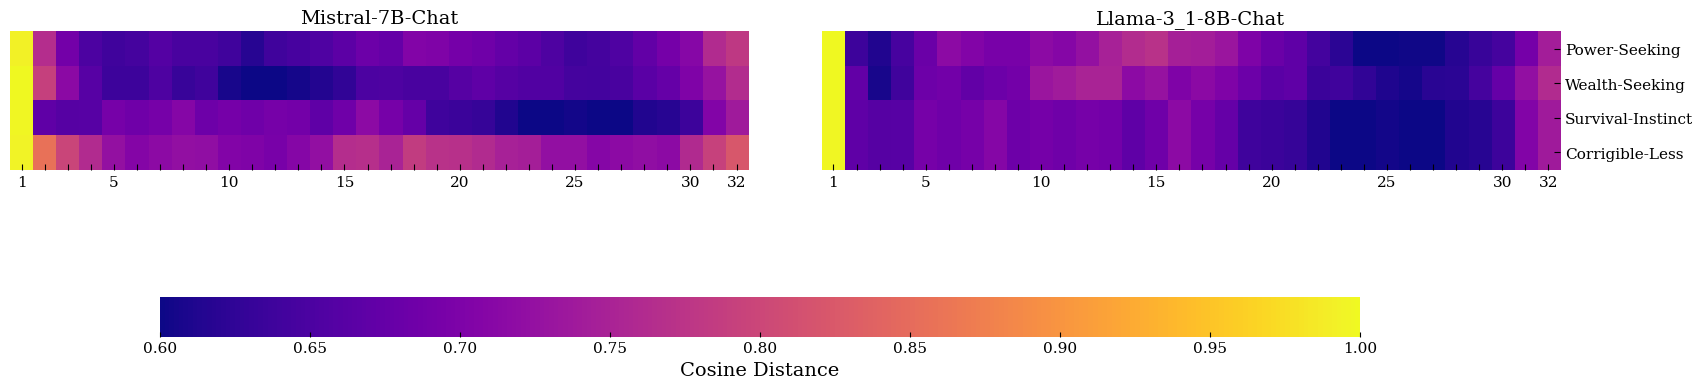

In [78]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    'Wealth-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_weal,
        'Llama-3_1-8B-Chat': llama_data_raw_weal
    },
    'Survival-Instinct': {
        'Mistral-7B-Chat': mistral_data_raw_survival,
        'Llama-3_1-8B-Chat': llama_data_raw_survival
    },
    'Corrigible-Less': {
        'Mistral-7B-Chat': mistral_data_raw_corri,
        'Llama-3_1-8B-Chat': llama_data_raw_corri
    }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Mean:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=0.6, vmax=1.0)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()

# Magniude

In [79]:
import os
import torch
import re

def compute_layer_norms(folder_path):
    """
    Loads .pt files from a specified folder that end with 'layerXX.pt' 
    (where XX is a number) regardless of the prefix, and computes their L2 norm.
    """
    if not os.path.exists(folder_path):
        print(f"Directory not found: {folder_path}")
        return

    pt_files = []
    # Regex pattern: 
    # .* -> matches any character (the random prefix)
    # layer  -> matches the literal word "layer"
    # (\d+)  -> captures one or more digits (the layer number)
    # \.pt$  -> matches exactly ".pt" at the end of the string
    pattern = re.compile(r'.*layer(\d+)\.pt$')

    # Scan the directory
    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        if match:
            filepath = os.path.join(folder_path, filename)
            layer_num = int(match.group(1))
            # Store as a tuple (filepath, layer_num) for easy sorting
            pt_files.append((filepath, layer_num))

    if not pt_files:
        print(f"No files ending with 'layerXX.pt' found in {folder_path}")
        return

    # Sort files numerically by the extracted layer number (the second item in our tuple)
    pt_files.sort(key=lambda x: x[1])

    # Print header (widened to accommodate potentially longer random prefixes)
    print(f"{'Filename':<35} | {'L2 Norm'}")
    print("-" * 55)

    # Iterate, load, and compute norm
    for filepath, layer_num in pt_files:
        filename = os.path.basename(filepath)
        
        try:
            # Load the tensor safely on CPU
            tensor = torch.load(filepath, map_location='cpu', weights_only=False)
            
            # Ensure it's a tensor before calculating the norm
            if isinstance(tensor, torch.Tensor):
                norm_value = torch.norm(tensor.float()).item()
                print(f"{filename:<35} | {norm_value:.4f}")
            
                
        except Exception as e:
            print(f"{filename:<35} | Error reading file: {e}")

# --- Execution ---
if __name__ == "__main__":
    target_folder = "/home/yosef/ws/thesis/pretrained_vector/power-seeking/llama-3/all" 
    compute_layer_norms(target_folder)

Filename                            | L2 Norm
-------------------------------------------------------
vec_ep3_layer0.pt                   | 0.3420
vec_ep3_layer1.pt                   | 0.3467
vec_ep3_layer2.pt                   | 0.3661
vec_ep3_layer3.pt                   | 0.3850
vec_ep3_layer4.pt                   | 0.4000
vec_ep3_layer5.pt                   | 0.4155
vec_ep3_layer6.pt                   | 0.4225
vec_ep3_layer7.pt                   | 0.4392
vec_ep3_layer8.pt                   | 0.4504
vec_ep3_layer9.pt                   | 0.4639
vec_ep3_layer10.pt                  | 0.4617
vec_ep3_layer11.pt                  | 0.4781
vec_ep3_layer12.pt                  | 0.4806
vec_ep3_layer13.pt                  | 0.5300
vec_ep3_layer14.pt                  | 0.5446
vec_ep3_layer15.pt                  | 0.5458
vec_ep3_layer16.pt                  | 0.5445
vec_ep3_layer17.pt                  | 0.5556
vec_ep3_layer18.pt                  | 0.5761
vec_ep3_layer19.pt                  | 0.571

# Baseline

In [80]:
# Your raw text data
mistral_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0103 | [Max:] 1.0117 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0096 | [Max:] 1.0039 [Min:] 0.9805
[Layer:] 2 | Cosine Distance [Mean:] 0.9863 [Std:] 0.0141 | [Max:] 1.0078 [Min:] 0.9727
[Layer:] 3 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0080 | [Max:] 1.0020 [Min:] 0.9805
[Layer:] 4 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0057 | [Max:] 1.0059 [Min:] 0.9883
[Layer:] 5 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0064 | [Max:] 1.0059 [Min:] 0.9844
[Layer:] 6 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0073 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 7 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0083 | [Max:] 1.0234 [Min:] 0.9785
[Layer:] 8 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0135 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 9 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0093 | [Max:] 1.0117 [Min:] 0.9766
[Layer:] 10 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0110 | [Max:] 1.0137 [Min:] 0.9688
[Layer:] 11 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0127 | [Max:] 1.0117 [Min:] 0.9688
[Layer:] 12 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0061 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 13 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0137 | [Max:] 1.0547 [Min:] 0.9746
[Layer:] 14 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0052 | [Max:] 1.0156 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0065 | [Max:] 1.0156 [Min:] 0.9844
[Layer:] 16 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0070 | [Max:] 1.0234 [Min:] 0.9844
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0162 | [Max:] 1.0469 [Min:] 0.9766
[Layer:] 18 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0079 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 19 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0112 | [Max:] 1.0312 [Min:] 0.9766
[Layer:] 20 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0079 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 21 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0086 | [Max:] 1.0234 [Min:] 0.9785
[Layer:] 22 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0114 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 23 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0086 | [Max:] 1.0234 [Min:] 0.9727
[Layer:] 24 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0126 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 25 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0107 | [Max:] 1.0234 [Min:] 0.9648
[Layer:] 26 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0152 | [Max:] 1.0469 [Min:] 0.9766
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0118 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 28 | Cosine Distance [Mean:] 1.0352 [Std:] 0.0398 | [Max:] 1.0938 [Min:] 0.9688
[Layer:] 29 | Cosine Distance [Mean:] 1.0430 [Std:] 0.0499 | [Max:] 1.1172 [Min:] 0.9688
[Layer:] 30 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0378 | [Max:] 1.0938 [Min:] 0.9629
[Layer:] 31 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0246 | [Max:] 1.0781 [Min:] 0.9434
"""

llama_data_raw_power = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 1 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0121 | [Max:] 1.0234 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0048 | [Max:] 1.0234 [Min:] 0.9902
[Layer:] 3 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0083 | [Max:] 1.0156 [Min:] 0.9941
[Layer:] 4 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0039 | [Max:] 1.0156 [Min:] 0.9902
[Layer:] 5 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0097 | [Max:] 1.0234 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0116 | [Max:] 1.0391 [Min:] 0.9863
[Layer:] 7 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0053 | [Max:] 1.0078 [Min:] 0.9805
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 9 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0065 | [Max:] 1.0117 [Min:] 0.9805
[Layer:] 10 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0112 | [Max:] 1.0078 [Min:] 0.9727
[Layer:] 11 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0087 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 12 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0146 | [Max:] 1.0391 [Min:] 0.9883
[Layer:] 13 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0041 | [Max:] 1.0156 [Min:] 0.9863
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0152 | [Max:] 1.0469 [Min:] 0.9746
[Layer:] 15 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0089 | [Max:] 1.0273 [Min:] 0.9688
[Layer:] 16 | Cosine Distance [Mean:] 0.9883 [Std:] 0.0148 | [Max:] 1.0273 [Min:] 0.9531
[Layer:] 17 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0118 | [Max:] 1.0391 [Min:] 0.9766
[Layer:] 18 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0155 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 19 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0147 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 20 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0283 | [Max:] 1.0703 [Min:] 0.9805
[Layer:] 21 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0263 | [Max:] 1.0625 [Min:] 0.9824
[Layer:] 22 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0200 | [Max:] 1.0469 [Min:] 0.9824
[Layer:] 23 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0155 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 24 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0106 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 25 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0144 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 26 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0227 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 27 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0068 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 28 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0174 | [Max:] 1.0469 [Min:] 0.9863
[Layer:] 29 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0181 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 30 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0297 | [Max:] 1.0703 [Min:] 0.9805
[Layer:] 31 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0265 | [Max:] 1.0781 [Min:] 0.9707
"""

In [81]:
# Your raw text data
mistral_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0048 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 1 | Cosine Distance [Mean:] 0.9863 [Std:] 0.0133 | [Max:] 1.0000 [Min:] 0.9727
[Layer:] 2 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0060 | [Max:] 1.0020 [Min:] 0.9883
[Layer:] 3 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0056 | [Max:] 1.0039 [Min:] 0.9844
[Layer:] 4 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0059 | [Max:] 1.0039 [Min:] 0.9844
[Layer:] 5 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0059 | [Max:] 1.0059 [Min:] 0.9844
[Layer:] 6 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0110 | [Max:] 1.0117 [Min:] 0.9766
[Layer:] 7 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0056 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 8 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0066 | [Max:] 1.0234 [Min:] 0.9863
[Layer:] 9 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0049 | [Max:] 1.0156 [Min:] 0.9883
[Layer:] 10 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0079 | [Max:] 1.0156 [Min:] 0.9766
[Layer:] 11 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0051 | [Max:] 1.0156 [Min:] 0.9863
[Layer:] 12 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0089 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 13 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0102 | [Max:] 1.0391 [Min:] 0.9824
[Layer:] 14 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0107 | [Max:] 1.0312 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0121 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 16 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0156 | [Max:] 1.0469 [Min:] 0.9785
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0163 | [Max:] 1.0391 [Min:] 0.9707
[Layer:] 18 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0144 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 19 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0172 | [Max:] 1.0469 [Min:] 0.9766
[Layer:] 20 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0117 | [Max:] 1.0312 [Min:] 0.9727
[Layer:] 21 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0111 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 22 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0107 | [Max:] 1.0234 [Min:] 0.9766
[Layer:] 23 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0136 | [Max:] 1.0312 [Min:] 0.9727
[Layer:] 24 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0116 | [Max:] 1.0312 [Min:] 0.9707
[Layer:] 25 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0109 | [Max:] 1.0312 [Min:] 0.9648
[Layer:] 26 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0138 | [Max:] 1.0391 [Min:] 0.9688
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0129 | [Max:] 1.0352 [Min:] 0.9609
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0136 | [Max:] 1.0391 [Min:] 0.9609
[Layer:] 29 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0173 | [Max:] 1.0391 [Min:] 0.9375
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0157 | [Max:] 1.0469 [Min:] 0.9609
[Layer:] 31 | Cosine Distance [Mean:] 0.9609 [Std:] 0.0488 | [Max:] 1.0508 [Min:] 0.8672
"""

llama_data_raw_weal = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0110 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 1 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0118 | [Max:] 1.0234 [Min:] 0.9980
[Layer:] 2 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0162 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 3 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0204 | [Max:] 1.0391 [Min:] 0.9902
[Layer:] 4 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0140 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 5 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0127 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 7 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0151 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 8 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0181 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0125 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 10 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0137 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 11 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0208 | [Max:] 1.0469 [Min:] 0.9883
[Layer:] 12 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0361 | [Max:] 1.0859 [Min:] 0.9805
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0085 | [Max:] 1.0234 [Min:] 0.9863
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0141 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0058 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 16 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0102 | [Max:] 1.0195 [Min:] 0.9648
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0138 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 18 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0227 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 19 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0222 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 20 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0335 | [Max:] 1.0859 [Min:] 0.9785
[Layer:] 21 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0213 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 22 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0219 | [Max:] 1.0547 [Min:] 0.9805
[Layer:] 23 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0242 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 24 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0163 | [Max:] 1.0391 [Min:] 0.9863
[Layer:] 25 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0236 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 26 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0252 | [Max:] 1.0625 [Min:] 0.9824
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0099 | [Max:] 1.0234 [Min:] 0.9844
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0077 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 29 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0098 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0136 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0131 | [Max:] 1.0352 [Min:] 0.9609
"""

In [82]:
# Your raw text data
mistral_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0156 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0071 | [Max:] 1.0156 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0125 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 3 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0005 | [Max:] 1.0000 [Min:] 0.9980
[Layer:] 4 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0076 | [Max:] 1.0059 [Min:] 0.9844
[Layer:] 5 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0028 | [Max:] 1.0039 [Min:] 0.9922
[Layer:] 6 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0015 | [Max:] 1.0078 [Min:] 0.9941
[Layer:] 7 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0139 | [Max:] 1.0352 [Min:] 0.9258
[Layer:] 8 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0086 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0099 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 10 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0042 | [Max:] 1.0156 [Min:] 0.9863
[Layer:] 11 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0039 | [Max:] 1.0156 [Min:] 0.9883
[Layer:] 12 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0088 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 13 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0061 | [Max:] 1.0078 [Min:] 0.9805
[Layer:] 14 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0069 | [Max:] 1.0078 [Min:] 0.9805
[Layer:] 15 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0139 | [Max:] 1.0391 [Min:] 0.9883
[Layer:] 16 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 17 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0195 [Min:] 0.9648
[Layer:] 18 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0164 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 19 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0159 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 20 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0079 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 21 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0064 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 22 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0109 | [Max:] 1.0391 [Min:] 0.9766
[Layer:] 23 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0139 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 24 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0134 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 25 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0085 | [Max:] 1.0312 [Min:] 0.9785
[Layer:] 26 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0135 | [Max:] 1.0391 [Min:] 0.9766
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0076 | [Max:] 1.0234 [Min:] 0.9785
[Layer:] 28 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0104 | [Max:] 1.0273 [Min:] 0.9688
[Layer:] 29 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0090 | [Max:] 1.0273 [Min:] 0.9688
[Layer:] 30 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0112 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0142 | [Max:] 1.0469 [Min:] 0.9570
"""

llama_data_raw_survival = """
[Layer:] 0 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0110 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 1 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0118 | [Max:] 1.0234 [Min:] 0.9980
[Layer:] 2 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0162 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 3 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0204 | [Max:] 1.0391 [Min:] 0.9902
[Layer:] 4 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0140 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 5 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0127 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0113 | [Max:] 1.0234 [Min:] 0.9922
[Layer:] 7 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0151 | [Max:] 1.0312 [Min:] 0.9922
[Layer:] 8 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0181 | [Max:] 1.0391 [Min:] 0.9785
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0125 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 10 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0137 | [Max:] 1.0312 [Min:] 0.9902
[Layer:] 11 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0208 | [Max:] 1.0469 [Min:] 0.9883
[Layer:] 12 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0361 | [Max:] 1.0859 [Min:] 0.9805
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0085 | [Max:] 1.0234 [Min:] 0.9863
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0141 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 15 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0058 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 16 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0102 | [Max:] 1.0195 [Min:] 0.9648
[Layer:] 17 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0138 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 18 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0227 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 19 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0222 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 20 | Cosine Distance [Mean:] 1.0312 [Std:] 0.0335 | [Max:] 1.0859 [Min:] 0.9785
[Layer:] 21 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0213 | [Max:] 1.0547 [Min:] 0.9863
[Layer:] 22 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0219 | [Max:] 1.0547 [Min:] 0.9805
[Layer:] 23 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0242 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 24 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0163 | [Max:] 1.0391 [Min:] 0.9863
[Layer:] 25 | Cosine Distance [Mean:] 1.0195 [Std:] 0.0236 | [Max:] 1.0547 [Min:] 0.9824
[Layer:] 26 | Cosine Distance [Mean:] 1.0234 [Std:] 0.0252 | [Max:] 1.0625 [Min:] 0.9824
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0099 | [Max:] 1.0234 [Min:] 0.9844
[Layer:] 28 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0077 | [Max:] 1.0234 [Min:] 0.9805
[Layer:] 29 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0098 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0136 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0131 | [Max:] 1.0352 [Min:] 0.9609
"""

In [83]:
# Your raw text data
mistral_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0095 | [Max:] 1.0117 [Min:] 0.9727
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0081 | [Max:] 1.0156 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0054 | [Max:] 1.0312 [Min:] 0.9883
[Layer:] 3 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0130 | [Max:] 1.0312 [Min:] 0.9941
[Layer:] 4 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0096 | [Max:] 1.0391 [Min:] 0.9844
[Layer:] 5 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0089 | [Max:] 1.0156 [Min:] 0.9902
[Layer:] 6 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0057 | [Max:] 1.0156 [Min:] 0.9902
[Layer:] 7 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0099 | [Max:] 1.0234 [Min:] 0.9902
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0052 | [Max:] 1.0117 [Min:] 0.9844
[Layer:] 9 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0103 | [Max:] 1.0156 [Min:] 0.9688
[Layer:] 10 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0063 | [Max:] 1.0156 [Min:] 0.9883
[Layer:] 11 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0145 | [Max:] 1.0312 [Min:] 0.9863
[Layer:] 12 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0109 | [Max:] 1.0312 [Min:] 0.9453
[Layer:] 13 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0098 | [Max:] 1.0312 [Min:] 0.9824
[Layer:] 14 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0160 | [Max:] 1.0469 [Min:] 0.9746
[Layer:] 15 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0119 | [Max:] 1.0391 [Min:] 0.9746
[Layer:] 16 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0119 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 17 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0131 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 18 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0135 | [Max:] 1.0234 [Min:] 0.9648
[Layer:] 19 | Cosine Distance [Mean:] 0.9824 [Std:] 0.0219 | [Max:] 1.0215 [Min:] 0.9453
[Layer:] 20 | Cosine Distance [Mean:] 0.9883 [Std:] 0.0163 | [Max:] 1.0195 [Min:] 0.9531
[Layer:] 21 | Cosine Distance [Mean:] 0.9922 [Std:] 0.0107 | [Max:] 1.0156 [Min:] 0.9648
[Layer:] 22 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0078 | [Max:] 1.0195 [Min:] 0.9727
[Layer:] 23 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0064 | [Max:] 1.0195 [Min:] 0.9805
[Layer:] 24 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0078 | [Max:] 1.0156 [Min:] 0.9805
[Layer:] 25 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0156 [Min:] 0.9688
[Layer:] 26 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0080 | [Max:] 1.0234 [Min:] 0.9824
[Layer:] 27 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0106 | [Max:] 1.0312 [Min:] 0.9785
[Layer:] 28 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0102 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 29 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0148 | [Max:] 1.0195 [Min:] 0.9531
[Layer:] 30 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0138 | [Max:] 1.0312 [Min:] 0.9746
[Layer:] 31 | Cosine Distance [Mean:] 0.9961 [Std:] 0.0212 | [Max:] 1.0469 [Min:] 0.9297
"""

llama_data_raw_corri = """
[Layer:] 0 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0040 | [Max:] 1.0117 [Min:] 0.9883
[Layer:] 1 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0093 | [Max:] 1.0234 [Min:] 0.9961
[Layer:] 2 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0147 | [Max:] 1.0547 [Min:] 0.9766
[Layer:] 3 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0094 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 4 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0180 | [Max:] 1.0469 [Min:] 0.9805
[Layer:] 5 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0065 | [Max:] 1.0156 [Min:] 0.9922
[Layer:] 6 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0140 | [Max:] 1.0234 [Min:] 0.9453
[Layer:] 7 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0153 | [Max:] 1.0469 [Min:] 0.9668
[Layer:] 8 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0071 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 9 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0150 | [Max:] 1.0391 [Min:] 0.9727
[Layer:] 10 | Cosine Distance [Mean:] 0.9980 [Std:] 0.0092 | [Max:] 1.0273 [Min:] 0.9648
[Layer:] 11 | Cosine Distance [Mean:] 1.0039 [Std:] 0.0139 | [Max:] 1.0391 [Min:] 0.9727
[Layer:] 12 | Cosine Distance [Mean:] 0.9805 [Std:] 0.0275 | [Max:] 1.0410 [Min:] 0.8945
[Layer:] 13 | Cosine Distance [Mean:] 0.9707 [Std:] 0.0349 | [Max:] 1.0332 [Min:] 0.8984
[Layer:] 14 | Cosine Distance [Mean:] 0.9746 [Std:] 0.0312 | [Max:] 1.0254 [Min:] 0.9141
[Layer:] 15 | Cosine Distance [Mean:] 0.9805 [Std:] 0.0214 | [Max:] 1.0156 [Min:] 0.9453
[Layer:] 16 | Cosine Distance [Mean:] 0.9766 [Std:] 0.0264 | [Max:] 1.0156 [Min:] 0.9375
[Layer:] 17 | Cosine Distance [Mean:] 0.9824 [Std:] 0.0210 | [Max:] 1.0156 [Min:] 0.9492
[Layer:] 18 | Cosine Distance [Mean:] 0.9844 [Std:] 0.0177 | [Max:] 1.0156 [Min:] 0.9531
[Layer:] 19 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0129 | [Max:] 1.0176 [Min:] 0.9648
[Layer:] 20 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0111 | [Max:] 1.0234 [Min:] 0.9688
[Layer:] 21 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0143 | [Max:] 1.0234 [Min:] 0.9609
[Layer:] 22 | Cosine Distance [Mean:] 0.9863 [Std:] 0.0171 | [Max:] 1.0195 [Min:] 0.9570
[Layer:] 23 | Cosine Distance [Mean:] 0.9746 [Std:] 0.0291 | [Max:] 1.0176 [Min:] 0.9297
[Layer:] 24 | Cosine Distance [Mean:] 0.9902 [Std:] 0.0134 | [Max:] 1.0176 [Min:] 0.9609
[Layer:] 25 | Cosine Distance [Mean:] 0.9805 [Std:] 0.0227 | [Max:] 1.0156 [Min:] 0.9453
[Layer:] 26 | Cosine Distance [Mean:] 0.9941 [Std:] 0.0097 | [Max:] 1.0195 [Min:] 0.9688
[Layer:] 27 | Cosine Distance [Mean:] 1.0078 [Std:] 0.0134 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 28 | Cosine Distance [Mean:] 1.0000 [Std:] 0.0089 | [Max:] 1.0195 [Min:] 0.9727
[Layer:] 29 | Cosine Distance [Mean:] 1.0117 [Std:] 0.0167 | [Max:] 1.0391 [Min:] 0.9805
[Layer:] 30 | Cosine Distance [Mean:] 1.0273 [Std:] 0.0336 | [Max:] 1.0781 [Min:] 0.9785
[Layer:] 31 | Cosine Distance [Mean:] 1.0156 [Std:] 0.0238 | [Max:] 1.0547 [Min:] 0.9648
"""

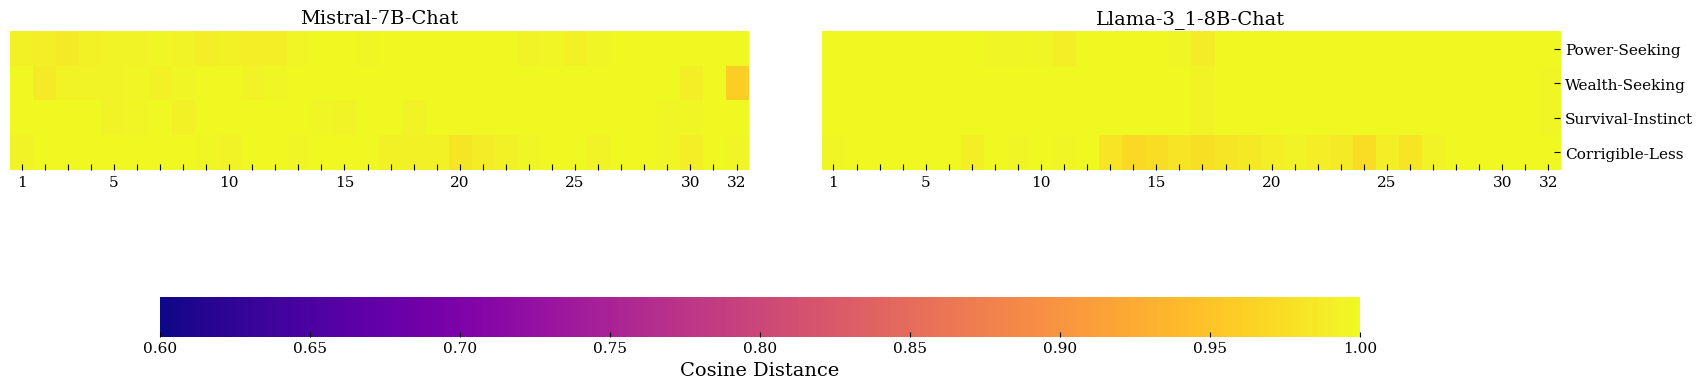

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import re


# 2. BUILD THE DICTIONARY NOW THAT VARIABLES EXIST
RES = {
    'Power-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_power,
        'Llama-3_1-8B-Chat': llama_data_raw_power
    },
    'Wealth-Seeking': {
        'Mistral-7B-Chat': mistral_data_raw_weal,
        'Llama-3_1-8B-Chat': llama_data_raw_weal
    },
    'Survival-Instinct': {
        'Mistral-7B-Chat': mistral_data_raw_survival,
        'Llama-3_1-8B-Chat': llama_data_raw_survival
    },
    'Corrigible-Less': {
        'Mistral-7B-Chat': mistral_data_raw_corri,
        'Llama-3_1-8B-Chat': llama_data_raw_corri
    }
}

# 3. PARSE AND PLOT
def parse_means(raw_text):
    means = []
    for line in raw_text.strip().split('\n'):
        if line.strip():
            match = re.search(r'\[Mean:\] ([\d.]+)', line)
            if match:
                means.append(float(match.group(1)))
    return means

models = ['Mistral-7B-Chat', 'Llama-3_1-8B-Chat']
datasets = list(RES.keys())
num_layers = 32

model_heatmaps = {model: [] for model in models}

for dataset in datasets:
    for model in models:
        means = parse_means(RES[dataset][model])
        model_heatmaps[model].append(means)

for model in models:
    model_heatmaps[model] = np.array(model_heatmaps[model])

plt.rcParams.update({
    'font.family': 'serif', 
    'font.size': 11, 
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 
    'ytick.direction': 'in', 
    'grid.alpha': 0.3
})

fig, axes = plt.subplots(ncols=len(models), figsize=(20, 4))
if len(models) == 1:
    axes = [axes]

global_min = min(model_heatmaps[m].min() for m in models)
global_max = max(model_heatmaps[m].max() for m in models)

for i, (ax, model) in enumerate(zip(axes, models)):
    data = model_heatmaps[model]
    
    im = ax.imshow(data, aspect=1.5, cmap='plasma', vmin=0.6, vmax=1.0)

    
    ax.set_title(model, loc='center', fontweight='light')
    
    ax.set_yticks(np.arange(len(datasets)))
    
    if i == len(models) - 1:
        ax.set_yticklabels(datasets)
        ax.yaxis.tick_right()
        ax.tick_params(axis='y', length=4)
    else:
        ax.set_yticklabels([]) 
        ax.tick_params(axis='y', length=0) 

    ax.set_xticks(np.arange(num_layers))
    xtick_labels = []
    for j in range(num_layers):
        layer_num = j + 1
        if layer_num == 1 or layer_num % 5 == 0 or layer_num == 32:
            xtick_labels.append(str(layer_num))
        else:
            xtick_labels.append('')
            
    ax.set_xticklabels(xtick_labels)
    ax.tick_params(axis='x', length=4)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.1]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cosine Distance')
cbar.outline.set_visible(False)

plt.subplots_adjust(bottom=0.2, wspace=0.1)
plt.show()